In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import json
import os

os.chdir("../")
from scripts import utils, alerceanomalies
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.svm import OneClassSVM
import distclassipy as dcpy
from distclassipy.anomaly import DistanceAnomaly
from sklearn.model_selection import train_test_split

from sklearn.base import BaseEstimator, OutlierMixin
epsilon = np.finfo(np.float32).eps
with open("settings.txt") as f:
    settings_dict = json.load(f)
seed_val = settings_dict["seed_choice"]
np.random.seed(seed_val)
sns_dict = settings_dict["sns_dict"]
sns.set_theme(**sns_dict)

from IPython.core.display import HTML
from IPython.display import display

import squarify
set3colors = [matplotlib.colors.rgb2hex(x) for x in plt.cm.Set3.colors]
knowncolors = set3colors[:4]
unknowncolors = ['#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#42d4f4', '#f032e6', '#bfef45', '#fabed4', '#469990', '#dcbeff', '#9A6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#a9a9a9']
unknowncolors = set3colors[4:]+unknowncolors

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

In [2]:
models_to_test = {
    "iForest": IsolationForest( #using alerce anomaly params
        n_estimators=100,
        max_samples=256,
        contamination=0.001,
        random_state=seed_val
    ),
    "LOF": LocalOutlierFactor(
        n_neighbors=20, 
        novelty=True,  # IMPORTANT: Allows use on new data
        contamination='auto'
    ),
    
    "OC-SVM": OneClassSVM(
        kernel='rbf',
        nu=0.001
    ),

    "Autoencoder": alerceanomalies.AutoencoderAnomalyDetector(
        encoding_dim=32, # Can be tuned
        epochs=500,
        patience=15,
    ),

    "MCSVDD": alerceanomalies.ClassSVDDAnomalyDetector(
        z_dim=64,
        epochs=500,
        patience=15,
        lr=1e-4,
        verbose=False
    ),
        
    "DiMMAD (med-med)": DistanceAnomaly(
        cluster_agg='median',
        metric_agg='median',
        normalize_scores=True
    ),

    "DiMMAD (min-med)": DistanceAnomaly(
        cluster_agg='min',
        metric_agg='median',
        normalize_scores=True
    ),

}

In [3]:
traindat = pd.read_pickle("data/alercedata/train_data_filtered.pkl").set_index("oid")
testdat = pd.read_pickle("data/alercedata/test_data_filtered.pkl").set_index("oid")
feature_list = pd.read_pickle("data/alercedata/features_BHRF_model.pkl")

commondat = pd.concat([traindat,testdat])
commondat=commondat.rename(columns={"classALeRCE":"class"})

In [4]:
new_knowns = ['SNIa','SNIbc', 'SNII',
              'RRL', 'LPV', 'E', 'QSO', 'YSO',  'AGN', 'CEP',
              'Periodic-Other', 'DSCT', 'Blazar', 'CV/Nova'
             ]

new_unknowns = ["SLSN"]

features_to_use = [
"SPM_A_1",
"SPM_t0_1",
"SPM_gamma_1",
"SPM_beta_1",
"SPM_tau_rise_1",
"SPM_tau_fall_1",
"SPM_chi_1",
"SPM_A_2",
"SPM_t0_2",
"SPM_gamma_2",
"SPM_beta_2",
"SPM_tau_rise_2",
"SPM_tau_fall_2",
"SPM_chi_2",
]

# Could use features we know are better for the 4 variable star classification
# but don't want to bias. additionally, the above features are simple and general
# and have very little NaNs.

In [5]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

In [6]:
all_classes = np.concatenate([new_knowns, new_unknowns])
full_df = commondat[commondat['class'].isin(all_classes)]
full_df = full_df.loc[:, list(features_to_use) + ["class"]].dropna(subset=features_to_use)
full_df = full_df[~full_df.index.duplicated(keep='first')]

# full_df['status'] = np.where(full_df['class'].isin(new_knowns), 'normal', 'anomalous')
# will use this for stratification

full_inlier_df = full_df[full_df["class"].isin(new_knowns)]
smallest_class_count = full_inlier_df["class"].value_counts().min()
full_outlier_df = full_df[full_df["class"].isin(new_unknowns)]

outlier_counts = full_outlier_df["class"].value_counts()
num_outlier_classes = len(outlier_counts)

---
---

In [7]:
mycolors = {
 'DiMMAD (min-med)': "#FFB000",
 'DiMMAD (med-med)': "#785EF0",
 'iForest': "#648FFF",
 'LOF': "#FE6100",
 'OC-SVM': "#DC267F",
 'Autoencoder': "#5F3331",
 'MCSVDD': "#6BC59D"
}

mylinestyles = {
 'DiMMAD (min-med)': 'solid',
 'DiMMAD (med-med)': 'solid',
 'iForest': 'dotted',
 'LOF': 'dashdot',
 'OC-SVM': 'dashed',
 'Autoencoder': (0, (3, 1, 1, 1)),
 'MCSVDD': (0, (5, 1))
}

In [8]:
N_RUNS = 20
all_results = {}
for unk in new_unknowns:
    all_results[unk] = []

for run in tqdm(range(N_RUNS),desc="Run #"):
    current_seed = seed_val + run
    
    # Balance inlier classes
    keep_indices = full_inlier_df.groupby("class").sample(smallest_class_count, random_state=current_seed).index
    inlier_df=full_inlier_df[full_inlier_df.index.isin(keep_indices)]
    thrown_inlier_df = inlier_df[~inlier_df.index.isin(keep_indices)]
    
    # Split balanced inliers into train/test
    inlier_train_df, inlier_test_df = train_test_split(
        inlier_df, test_size=0.5, random_state=current_seed,
        stratify=inlier_df['class'],
    )
    
    tot_inliers_in_test = inlier_test_df["class"].value_counts().sum()
    
    X_train_df = inlier_train_df[features_to_use]
    y_train_df = inlier_train_df['class']
    
    trained_models = {}
    for model_name, model_template in tqdm(models_to_test.items(),desc="Training models", leave=False):
        model = clone(model_template)
    
        if 'random_state' in model.get_params():
            model.set_params(random_state=current_seed)
        
        if "DiMMAD" in model_name or "MCSVDD" in model_name:
            model.fit(X_train_df.to_numpy(), y_train_df.to_numpy())
        else:
            model.fit(X_train_df.to_numpy())
    
        trained_models[model_name] = model

    
    for unk in tqdm(new_unknowns,desc="unk class pred", leave=False):
        # print("*"*20, unk, "*"*20)
        outlier_df = full_outlier_df[full_outlier_df['class'] == unk]
    
        choose_outliers = int(min(2/100 * tot_inliers_in_test, len(outlier_df)))
        outlier_df=outlier_df.sample(n=choose_outliers)
    
        X_test_df = pd.concat([inlier_test_df[features_to_use], outlier_df[features_to_use]])
        y_test_df = pd.concat([inlier_test_df['class'], outlier_df['class']]).loc[X_test_df.index]
        
        # print(f"AFTER Anom {unk}%: {(y_test_df.value_counts(normalize=True)[unk]):.2%}")
        
        results_df = pd.DataFrame(index=X_test_df.index)
        results_df['class'] = y_test_df
        mask = results_df['class'].isin(new_knowns)
        results_df['status'] = np.where(mask, 'normal', 'anomalous')
        
        for model_name, model_template in models_to_test.items():
            model = trained_models[model_name]
            scores = model.decision_function(X_test_df.to_numpy())
            if model_name in ["iForest", "LOF", "OC-SVM"]:
                scores = -scores
        
            results_df[f'score_{model_name}'] = scores

        all_results[unk].append(results_df)

Run #:   0%|          | 0/20 [00:00<?, ?it/s]

Training models:   0%|          | 0/7 [00:00<?, ?it/s]

Training AE:   0%|          | 0/500 [00:00<?, ?it/s]

Early stopping triggered.


Training ClassSVDD:   0%|          | 0/500 [00:00<?, ?it/s]

...

Training AE:   0%|          | 0/500 [00:00<?, ?it/s]

Early stopping triggered.


Training ClassSVDD:   0%|          | 0/500 [00:00<?, ?it/s]

Early stopping triggered.


unk class pred:   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
import pickle
with open("06. paper neurips mlps/results/exp8EXPERIMENTAL_results.pkl","wb") as fp:
    pickle.dump(all_results, fp)

In [10]:
final_fracs = {}
for unk in tqdm(new_unknowns,desc="unk class pred", leave=False):
    final_fracs[unk] = {}
    big_fracs = {}
    dflist = all_results[unk]
    
    for run_num in range(len(dflist)):
        results_df = dflist[run_num]
        fracs = {}
        for model_name in models_to_test.keys():
            subdf = results_df.sort_values(by=f"score_{model_name}",ascending=False)
            frac_vals = []
            # tot_anom = len(subdf[subdf["status"]=="anomalous"])
            for top_n in range(1,200):
                vcs = subdf["status"].iloc[:top_n].value_counts()
                if "anomalous" in vcs.index:
                    frac_correct = vcs["anomalous"]# / tot_anom
                else:
                    frac_correct=0
                frac_vals.append(frac_correct)
            fracs[model_name] = frac_vals
        big_fracs[f"run{run_num}"]=fracs
    for model_name in models_to_test.keys():
        all_vals_ls = []
        for run_num in range(len(dflist)):
            all_vals_ls.append(big_fracs[f"run{run_num}"][model_name])
        means = np.mean(np.array(all_vals_ls),axis=0)
        stds = np.std(np.array(all_vals_ls),axis=0)
        final_fracs[unk][model_name] = {"means":means, "stds":stds}

unk class pred:   0%|          | 0/1 [00:00<?, ?it/s]

unk class pred:   0%|          | 0/1 [00:00<?, ?it/s]

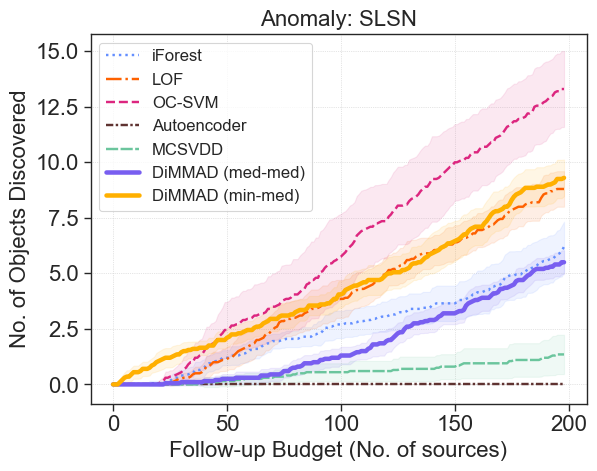

In [11]:
for unk in tqdm(new_unknowns,desc="unk class pred", leave=False):
    for model_name in models_to_test.keys():
        lw = 3.25 if "DiMMAD" in model_name else 1.75
        mean_curve = final_fracs[unk][model_name]["means"]
        std_curve = final_fracs[unk][model_name]["stds"]
        p = plt.plot(mean_curve, label=model_name, linewidth=lw, color=mycolors[model_name], linestyle=mylinestyles[model_name])
        plt.fill_between(np.arange(len(mean_curve)), 
                         mean_curve - 0.5*std_curve, 
                         mean_curve + 0.5*std_curve, 
                         color=p[0].get_color(), alpha=0.1)
    plt.xlabel("Follow-up Budget (No. of sources)", fontsize=16)
    plt.ylabel("No. of Objects Discovered", fontsize=16)
    plt.title(f"Anomaly: {unk}", fontsize=16)
    plt.gca().tick_params(axis='both', which='major', labelsize=16)
    plt.gca().tick_params(axis='both', which='minor', labelsize=12)
    # legend = plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12)
    legend = plt.legend(loc='upper left', fontsize=12)
    plt.grid(True, which="both", linestyle=":", linewidth=0.5)
    plt.savefig(f"06. paper neurips mlps/plots/Exp8/{unk}.pdf", bbox_inches="tight")
    plt.show()